# Notebook 3 — Data Modeling & Before/After Impact Analysis
**Star schema over resolved entities + quantified ROI of entity resolution.**

```
                DimProduct ─┐
                DimPharmacy ─┤
                DimRep ──────┼──> FactSales (grain = invoice line)
                DimSupplier ─┤
                DimDate ─────┘
```
Two analysis passes, by design:
1. **Per-supplier (pre-unification)** — each warehouse on its own keys, the only honest view before resolution;
2. **Unified (post-unification)** — on master IDs, then a **before/after comparison** quantifying exactly what entity resolution changed: fragmented revenue, ranking shifts, true top entities.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None); pd.set_option('display.width', 220)

fact_src = pd.read_csv('resolved_sales.csv', parse_dates=['tx_date'])
prod_m   = pd.read_csv('master_products.csv')
pharm_m  = pd.read_csv('master_pharmacies.csv')
rep_m    = pd.read_csv('master_reps.csv')
print(f"fact rows: {len(fact_src):,}")

fact rows: 9,989


## 1. Dimensions
### DimRep — with a `rep_type` flag
Several "reps" are not people but **system/channel accounts** (كلاستر، اي سبلاي، توريد، تحصيل، فارما لينك). Tagging them prevents the classic embarrassment of a leaderboard crowned by a software account.

In [2]:
CHANNEL_PAT = r'كلاستر|كليستر|سبلاي|سبلاى|توريد|تحصيل|فارما لينك|اوميت|اومت|cluster|supply|omit|سيلز \d+$'
dim_rep = (rep_m.groupby('rep_canonical', dropna=False)
                 .agg(n_source_entries=('rep_name_raw','nunique'),
                      suppliers=('supplier_id','nunique'),
                      tx=('tx','sum'), revenue=('revenue','sum')).reset_index())
dim_rep['rep_canonical'] = dim_rep['rep_canonical'].fillna('UNKNOWN')
dim_rep['rep_type'] = np.where(dim_rep['rep_canonical'].str.lower().str.contains(CHANNEL_PAT, regex=True), 'channel',
                      np.where(dim_rep['rep_canonical']=='UNKNOWN', 'unknown', 'person'))
dim_rep.insert(0, 'rep_key', range(1, len(dim_rep)+1))
print(dim_rep['rep_type'].value_counts().to_dict())
dim_rep[dim_rep['rep_type']=='channel'][['rep_canonical','suppliers','revenue']].head(8)

{'person': 93, 'channel': 12, 'unknown': 1}


,rep_canonical,suppliers,revenue
0,CLUSTER,2,14454.08
1,I-SUPPLY2,1,10353.22
21,اومت,1,8.51
22,اوميت,3,120243.63
23,اى سبلاى ختم,1,5326.25
24,اي سبلاي,6,71696.42
28,تحصيل سبلاي 3,1,2647.16
29,توريد,4,34600.64


### DimProduct, DimPharmacy, DimSupplier, DimDate

In [3]:
dim_product = (prod_m.groupby(['master_idx','canonical_name'])
                     .agg(n_name_variants=('product_name','nunique'),
                          base_name=('base_name','first'), strength=('strength','first'),
                          form=('form','first'), manufacturer=('manufacturer','first')).reset_index())
dim_product.insert(0, 'product_key', range(1, len(dim_product)+1))

dim_pharmacy = (pharm_m.groupby(['pharmacy_master_idx','pharmacy_canonical'])
                       .agg(n_source_accounts=('account_id','nunique'),
                            n_suppliers=('supplier_id','nunique'),
                            address=('address','first')).reset_index())
dim_pharmacy.insert(0, 'pharmacy_key', range(1, len(dim_pharmacy)+1))

dim_supplier = fact_src.groupby('supplier_id').agg(
    first_tx=('tx_date','min'), last_tx=('tx_date','max'), rows=('id','count')).reset_index()
dim_supplier['coverage_days'] = (dim_supplier['last_tx']-dim_supplier['first_tx']).dt.days
dim_supplier.insert(0, 'supplier_key', range(1, len(dim_supplier)+1))

dr = pd.date_range(fact_src['tx_date'].min().normalize(), fact_src['tx_date'].max().normalize())
dim_date = pd.DataFrame({'date': dr})
dim_date['date_key'] = dim_date['date'].dt.strftime('%Y%m%d').astype(int)
dim_date['year'] = dim_date['date'].dt.year; dim_date['month'] = dim_date['date'].dt.month
dim_date['year_month'] = dim_date['date'].dt.to_period('M').astype(str)
dim_date['dow'] = dim_date['date'].dt.day_name()

print(f"DimProduct: {len(dim_product):,} | DimPharmacy: {len(dim_pharmacy):,} | "
      f"DimRep: {len(dim_rep)} | DimSupplier: {len(dim_supplier)} | DimDate: {len(dim_date):,}")

DimProduct: 4,370 | DimPharmacy: 1,100 | DimRep: 106 | DimSupplier: 10 | DimDate: 1,429


## 2. FactSales
Grain: one invoice line. Master surrogate keys + degenerate source keys (`supplier_id`, original `prod_id`/`account_id`) retained for full lineage back to each warehouse.

In [4]:
fact = fact_src.merge(dim_product[['master_idx','product_key']],
                      left_on='product_master_id', right_on='master_idx', how='left') \
               .merge(dim_pharmacy[['pharmacy_master_idx','pharmacy_key']],
                      left_on='pharmacy_master_id', right_on='pharmacy_master_idx', how='left')
rep_map = rep_m.copy(); rep_map['rep_canonical'] = rep_map['rep_canonical'].fillna('UNKNOWN')
rep_map = rep_map.merge(dim_rep[['rep_canonical','rep_key','rep_type']], on='rep_canonical', how='left')
fact = fact.merge(rep_map[['supplier_id','rep_name_raw','rep_key','rep_type']],
                  on=['supplier_id','rep_name_raw'], how='left')
fact['date_key'] = fact['tx_date'].dt.strftime('%Y%m%d').astype(int)
fact_cols = ['id','invoice_id','date_key','tx_date','supplier_id','product_key','pharmacy_key',
             'rep_key','rep_type','prod_id','account_id','quantity','discount','total_amount',
             'is_amount_outlier']
fact = fact[fact_cols]
assert fact[['product_key','pharmacy_key','rep_key']].notna().all().all()
print(f"FactSales: {fact.shape} | revenue total: EGP {fact['total_amount'].sum():,.0f}")
fact.head(3)

FactSales: (9989, 15) | revenue total: EGP 2,592,185


,id,invoice_id,date_key,tx_date,supplier_id,product_key,pharmacy_key,rep_key,rep_type,prod_id,account_id,quantity,discount,total_amount,is_amount_outlier
0,48652728,32259,20250525,2025-05-25 13:43:10,59,1,14,102,person,7,637,10,15.0,178.50,False
1,48652935,32281,20250525,2025-05-25 14:35:04,59,1,139,102,person,7,4365,3,15.0,53.55,False
2,48653089,32301,20250525,2025-05-25 15:21:21,59,1,93,17,person,7,3297,2,21.0,33.18,False


## 3. Pass 1 — per-supplier analytics (pre-unification)
Each warehouse on its own raw names: the only valid analysis before resolution. Also exposes how differently warehouses behave (coverage, pricing, discount policy).

In [5]:
per_sup = fact_src.groupby('supplier_id').agg(
    revenue=('total_amount','sum'), transactions=('id','count'),
    avg_discount=('discount','mean'), pharmacies=('account_id','nunique'),
    products=('prod_id','nunique')).round(1)
per_sup['top_product_raw'] = fact_src.groupby(['supplier_id','product_name'])['total_amount'] \
    .sum().groupby('supplier_id').idxmax().str[1]
per_sup

,revenue,transactions,avg_discount,pharmacies,products,top_product_raw
supplier_id,,,,,,
59,77241.1,1000,19.9,314,7,تيراميسين مرهم للعين س-ج *
60,142227.6,1000,23.8,50,709,اوجمنتين 1جم 14ق س ج/المهن لــ جلاكسو
63,252679.3,1000,22.9,3,651,فيتاسيد سي 1جم12ق فوار س ج/سيد
67,182541.5,1000,26.0,56,668,ايبينام 500 فيال مثيل تينام
69,169811.1,1000,26.8,73,667,سوماتروبين امبول
72,346925.8,990,28.3,93,636,فيروجلوبين كبسول قديم
73,37738.4,1000,28.3,445,9,جاراميسين مرهم
75,329084.8,1000,24.0,20,650,بانتولوك 40 مجم 14قرص
76,458462.3,1000,24.7,43,541,بانادول ادفانس اقراص 4 شريط


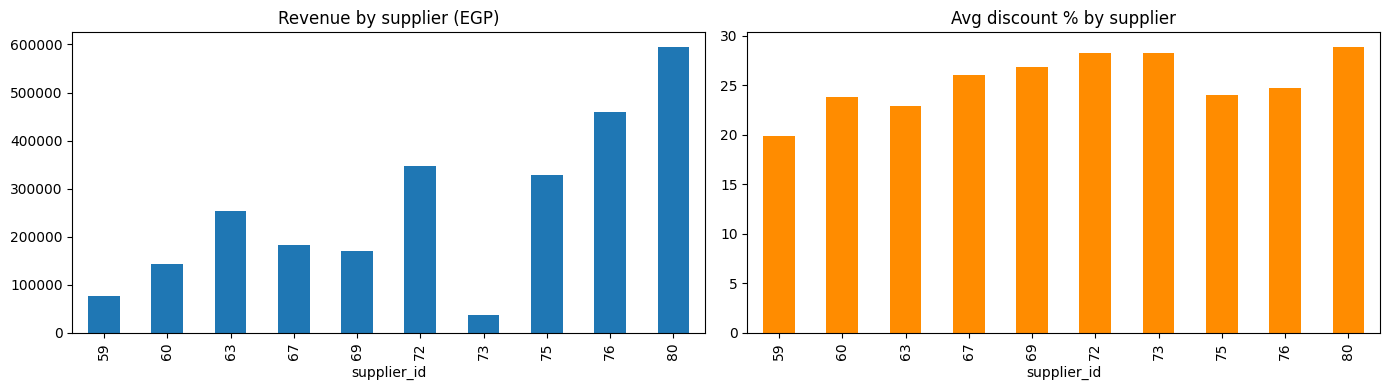

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
per_sup['revenue'].plot(kind='bar', ax=axes[0], title='Revenue by supplier (EGP)')
per_sup['avg_discount'].plot(kind='bar', ax=axes[1], color='darkorange', title='Avg discount % by supplier')
plt.tight_layout()

## 4. Pass 2 — the Before/After impact of entity resolution
**Before** = aggregating on raw `product_name` strings (what a naive analysis would do).
**After** = aggregating on `product_key` masters.
The difference is the measured ROI of Notebook 2.

In [7]:
# ---- fragmentation: how much revenue sat under entities split across multiple names? ----
frag_prod = dim_product[dim_product['n_name_variants']>1]
rev_by_master = fact.groupby('product_key')['total_amount'].sum()
frag_revenue = rev_by_master[rev_by_master.index.isin(frag_prod['product_key'])].sum()
total_rev = fact['total_amount'].sum()
print(f"products that existed under multiple names: {len(frag_prod):,} masters "
      f"({frag_prod['n_name_variants'].sum():,} raw names)")
print(f"revenue previously fragmented across name variants: EGP {frag_revenue:,.0f} "
      f"= {frag_revenue/total_rev*100:.1f}% of total revenue")
frag_ph = dim_pharmacy[dim_pharmacy['n_source_accounts']>1]
print(f"pharmacies unified across suppliers: {len(frag_ph)} "
      f"| reps unified from multiple spellings: {(dim_rep['n_source_entries']>1).sum()}")

products that existed under multiple names: 474 masters (1,149 raw names)
revenue previously fragmented across name variants: EGP 747,907 = 28.9% of total revenue
pharmacies unified across suppliers: 3 | reps unified from multiple spellings: 11


In [8]:
# ---- top-15 products: BEFORE (raw names) vs AFTER (masters) ----
before = fact_src.groupby('product_name')['total_amount'].sum().nlargest(15).reset_index()
before.columns = ['entity_BEFORE (raw name)','revenue_BEFORE']
after_g = fact.merge(dim_product[['product_key','canonical_name','n_name_variants']], on='product_key') \
              .groupby(['canonical_name','n_name_variants'])['total_amount'].sum().nlargest(15).reset_index()
after_g.columns = ['entity_AFTER (master)','n_variants','revenue_AFTER']
side = pd.concat([before, after_g], axis=1)
side

,entity_BEFORE (raw name),revenue_BEFORE,entity_AFTER (master),n_variants,revenue_AFTER
0,ميراج 1جم حقن,373520.00,ميراج 1جم حقن,1,373520.00
1,بانادول ادفانس اقراص 4 شريط,78071.64,بانادول ادفانس 4شريط,4,82489.48
2,اورازون شراب س ج,62693.64,اورازون شراب س ج,2,62817.48
3,تيراميسين مرهم للعين س-ج *,55764.52,تيراميسين مرهم للعين س-ج *,3,56168.84
4,دايسينون 500 - اقراص س ج,43316.00,دايسينون 500 - اقراص س ج,1,43316.00
5,بروليا حقن,38649.78,بروليا حقن,1,38649.78
6,ترايكتين اقراص س ج,31498.80,ترايكتين اقراص س ج,3,32039.30
7,جيفيسكون ادفانس ينسون شراب,25456.68,جاراميسين مرهم,2,30777.12
8,ازارجا نقط 5مل س ج,23823.80,جيفيسكون ادفانس ينسون شراب,1,25456.68
9,بانتولوك 40 مجم 14قرص,21390.42,ازارجا نقط 5مل س ج,1,23823.80


In [9]:
# ---- ranking shifts caused by unification ----
rank_before_raw = fact_src.groupby('product_name')['total_amount'].sum().rank(ascending=False)
name2master = prod_m.set_index('product_name')['master_idx']
rank_after = fact.merge(dim_product[['product_key','master_idx']], on='product_key') \
                 .groupby('master_idx')['total_amount'].sum().rank(ascending=False)
# best pre-unification rank among each master's variants vs its unified rank
variants = prod_m.groupby('master_idx')['product_name'].apply(list)
shifts = []
for m, names in variants.items():
    if len(names) < 2: continue
    best_before = min(rank_before_raw.get(n, np.inf) for n in names)
    shifts.append((m, len(names), best_before, rank_after.get(m, np.nan)))
sh = pd.DataFrame(shifts, columns=['master_idx','n_variants','best_rank_before','rank_after']) \
       .assign(rank_gain=lambda d: d['best_rank_before']-d['rank_after']) \
       .sort_values('rank_gain', ascending=False)
sh = sh.merge(dim_product[['master_idx','canonical_name']], on='master_idx')
print("biggest climbers — products whose true size was hidden by name fragmentation:")
sh.head(10)[['canonical_name','n_variants','best_rank_before','rank_after','rank_gain']]

biggest climbers — products whose true size was hidden by name fragmentation:


,canonical_name,n_variants,best_rank_before,rank_after,rank_gain
0,اوكتوزنك 20كبسول س ج,4,2747.0,995.0,1752.0
1,ديامونريكتا 5مجم 30قرص,3,2758.0,1021.0,1737.0
2,وان تو ثرى شراب 120مل س ق/حكمة,6,2255.0,519.0,1736.0
3,ريمواكس نقط,3,3510.0,1829.0,1681.0
4,فيرميزول شرب,3,3507.0,1842.0,1665.0
5,اميبازول 1جم 2ق/ايجيفار,3,3515.0,1929.0,1586.0
6,ايزيس ينسون 12 فلتر,4,2650.5,1098.0,1552.5
7,فيسرالجين شراب/سيديكو,3,3390.5,1853.0,1537.5
8,ايراستابكس بلس 40م,3,2742.0,1205.0,1537.0
9,حلمه ببرونه فلاى بيبىM,2,3919.5,2425.0,1494.5


In [10]:
# ---- the same comparison for pharmacies (true top customers) ----
ph_after = fact.merge(dim_pharmacy[['pharmacy_key','pharmacy_canonical','n_suppliers']], on='pharmacy_key') \
               .groupby(['pharmacy_canonical','n_suppliers'])['total_amount'].sum().nlargest(10).reset_index()
ph_after.columns = ['pharmacy (master)','suppliers_buying_from','revenue']
print("true top customers (post-unification). multi-supplier pharmacies were undercounted before:")
ph_after

true top customers (post-unification). multi-supplier pharmacies were undercounted before:


,pharmacy (master),suppliers_buying_from,revenue
0,فارم احمد عبدالله المنصوره,1,372736.00
1,ص/ياسر فتحى فيصل توصيل م س +,1,250230.96
2,عميل مخزن الجمله,1,228749.77
3,مخزن الامراء,1,120148.28
4,الاصدقاء العريش 8,1,98742.45
5,ص/هبه ابو زارع المنيب خط2,1,98077.85
6,حسام محمود,1,75084.76
7,ص الحصرى/الصفا والمروه/فيصل1,1,67043.86
8,ص/نقدى الموظفين,1,52539.90
9,ص/نشوى سمير003,1,46413.64


In [11]:
# ---- top reps: persons only, channels excluded ----
rep_lead = fact[fact['rep_type']=='person'] \
    .merge(dim_rep[['rep_key','rep_canonical']], on='rep_key') \
    .groupby('rep_canonical').agg(revenue=('total_amount','sum'),
                                  transactions=('id','count'),
                                  suppliers=('supplier_id','nunique')) \
    .nlargest(10, 'revenue').round(0)
ch_rev = fact.loc[fact['rep_type']=='channel','total_amount'].sum()
un_rev = fact.loc[fact['rep_type']=='unknown','total_amount'].sum()
print(f"channel-account revenue (excluded from leaderboard): EGP {ch_rev:,.0f}")
print(f"unattributable (UNKNOWN rep): EGP {un_rev:,.0f}")
rep_lead

channel-account revenue (excluded from leaderboard): EGP 318,965
unattributable (UNKNOWN rep): EGP 82,212


,revenue,transactions,suppliers
rep_canonical,,,
أ / محمد محروس,286792.0,434,1
محمد شعبان عبد الوهاب,250231.0,984,1
هيثم محمود,188609.0,11,1
م جديد,186368.0,1,1
SARA,124508.0,309,1
MOSTAFA,120085.0,301,1
محمد انور مسائى,99817.0,37,1
م محمد معوض,98742.0,318,1
د ميار,94812.0,495,1


## 5. Trends — honestly
Monthly revenue **per supplier**, because the unified monthly aggregate is dominated by export-window artifacts (supplier 60 = one day, 69 = two days, 76 = 2022–24 history). Cross-supplier trend claims are only valid inside overlapping windows.

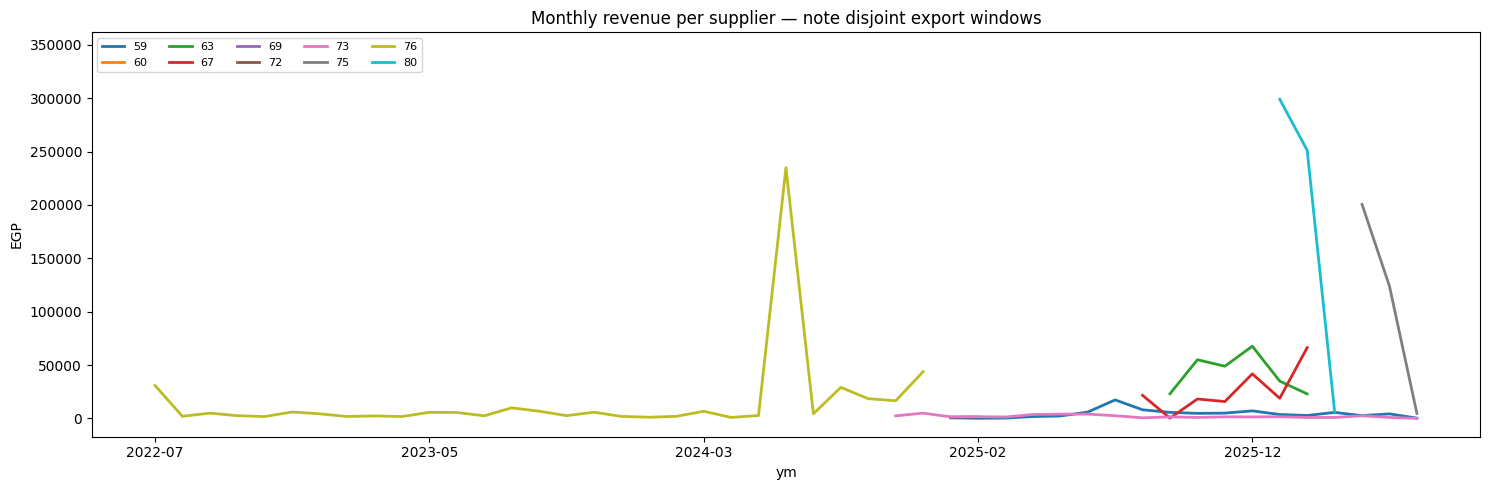

In [12]:
piv = fact_src.assign(ym=fact_src['tx_date'].dt.to_period('M').astype(str)) \
              .pivot_table(index='ym', columns='supplier_id', values='total_amount', aggfunc='sum')
ax = piv.plot(figsize=(15,5), title='Monthly revenue per supplier — note disjoint export windows', lw=2)
ax.set_ylabel('EGP'); plt.legend(ncol=5, fontsize=8); plt.tight_layout()

## 6. Outputs — warehouse tables for the dashboard and Notebook 4

In [13]:
import os
os.makedirs('warehouse', exist_ok=True)
for name, df_ in [('fact_sales',fact),('dim_product',dim_product),('dim_pharmacy',dim_pharmacy),
                  ('dim_rep',dim_rep),('dim_supplier',dim_supplier),('dim_date',dim_date)]:
    df_.to_csv(f'warehouse/{name}.csv', index=False)

impact = {
 'masters_with_multiple_names': int(len(frag_prod)),
 'fragmented_revenue_egp': float(frag_revenue),
 'fragmented_revenue_pct': round(float(frag_revenue/total_rev*100),1),
 'pharmacies_unified': int(len(frag_ph)),
 'reps_unified': int((dim_rep['n_source_entries']>1).sum()),
 'channel_revenue_egp': float(ch_rev),
}
pd.Series(impact).to_json('warehouse/impact_summary.json')
print('warehouse/: fact_sales, dim_product, dim_pharmacy, dim_rep, dim_supplier, dim_date, impact_summary.json')
print(impact)

warehouse/: fact_sales, dim_product, dim_pharmacy, dim_rep, dim_supplier, dim_date, impact_summary.json
{'masters_with_multiple_names': 474, 'fragmented_revenue_egp': 747906.9299999999, 'fragmented_revenue_pct': 28.9, 'pharmacies_unified': 3, 'reps_unified': 11, 'channel_revenue_egp': 318964.53}


---
**Next:** Notebook 4 — forecasting on master products (within valid supplier windows) + anomaly detection. The dashboard consumes `warehouse/` directly.